# Autism Screening - Model Training & Evaluation
## Building Baseline and Advanced ML Models

## Step 1: Load Data and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv('../data/autism_screening.csv')

print(f'Dataset Shape: {df.shape}')
print(f'\nFirst rows:')
print(df.head())
print(f'\nTarget Distribution:')
print(df['Class'].value_counts())

Dataset Shape: (704, 19)

First rows:
   A1_prefer_detail_not_big_picture  A2_must_have_sameness  \
0                                 0                      0   
1                                 1                      0   
2                                 0                      1   
3                                 0                      1   
4                                 0                      1   

   A3_prefer_reading_systematically  A4_feel_anxious_in_social  \
0                                 0                          1   
1                                 1                          0   
2                                 1                          0   
3                                 1                          1   
4                                 0                          0   

   A5_prefer_talking_one_to_one  A6_notice_small_changes  \
0                             1                        0   
1                             0                        0   
2           

## Step 2: Data Preprocessing & Feature Encoding

In [3]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f'\nCategorical columns ({len(categorical_cols)}): {categorical_cols}')
print(f'Numeric columns ({len(numeric_cols)}): {numeric_cols}')

Features shape: (704, 18)
Target shape: (704,)

Categorical columns (7): ['gender', 'ethnicity', 'jundice', 'autism_family_member', 'country', 'used_app_before', 'screening_type']
Numeric columns (11): ['A1_prefer_detail_not_big_picture', 'A2_must_have_sameness', 'A3_prefer_reading_systematically', 'A4_feel_anxious_in_social', 'A5_prefer_talking_one_to_one', 'A6_notice_small_changes', 'A7_trouble_focus_on_changing', 'A8_often_daydream', 'A9_focused_on_one_topic', 'A10_difficult_small_talk', 'age']


In [4]:
# Encode categorical variables
le_dict = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    le_dict[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f'\nTarget encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')

print(f'\nProcessed data shape: {X_encoded.shape}')
print(X_encoded.head())

gender: {'F': np.int64(0), 'M': np.int64(1)}
ethnicity: {'Asian': np.int64(0), 'Black': np.int64(1), 'Others': np.int64(2), 'White': np.int64(3)}
jundice: {'no': np.int64(0), 'yes': np.int64(1)}
autism_family_member: {'no': np.int64(0), 'yes': np.int64(1)}
country: {'Canada': np.int64(0), 'India': np.int64(1), 'UK': np.int64(2), 'USA': np.int64(3)}
used_app_before: {'no': np.int64(0), 'yes': np.int64(1)}
screening_type: {'Interview': np.int64(0), 'Questionnaire': np.int64(1)}

Target encoding: {'NO': np.int64(0), 'YES': np.int64(1)}

Processed data shape: (704, 18)
   A1_prefer_detail_not_big_picture  A2_must_have_sameness  \
0                                 0                      0   
1                                 1                      0   
2                                 0                      1   
3                                 0                      1   
4                                 0                      1   

   A3_prefer_reading_systematically  A4_feel_anxious_in

## Step 3: Train-Test Split

In [5]:
# Split data (70-30 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f'Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X_encoded)*100:.1f}%)')
print(f'Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X_encoded)*100:.1f}%)')

print(f'\nTraining set class distribution:')
print(pd.Series(y_train).value_counts().sort_index())
print(f'\nTest set class distribution:')
print(pd.Series(y_test).value_counts().sort_index())

Training set size: 492 (69.9%)
Test set size: 212 (30.1%)

Training set class distribution:
0    256
1    236
Name: count, dtype: int64

Test set class distribution:
0    110
1    102
Name: count, dtype: int64


## Step 4: Feature Scaling

In [6]:
# Scale numeric features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print('✅ Feature scaling completed')
print(f'\nScaled training data statistics:')
print(X_train_scaled[numeric_cols].describe())

✅ Feature scaling completed

Scaled training data statistics:
       A1_prefer_detail_not_big_picture  A2_must_have_sameness  \
count                      4.920000e+02           4.920000e+02   
mean                      -5.415722e-18          -4.513102e-17   
std                        1.001018e+00           1.001018e+00   
min                       -1.062953e+00          -9.293204e-01   
25%                       -1.062953e+00          -9.293204e-01   
50%                        9.407749e-01          -9.293204e-01   
75%                        9.407749e-01           1.076055e+00   
max                        9.407749e-01           1.076055e+00   

       A3_prefer_reading_systematically  A4_feel_anxious_in_social  \
count                      4.920000e+02               4.920000e+02   
mean                       1.299773e-16              -1.317826e-16   
std                        1.001018e+00               1.001018e+00   
min                       -9.798772e-01              -1.016395e

## Step 5: Train Baseline Model - Logistic Regression

In [7]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
print('🎯 LOGISTIC REGRESSION - PERFORMANCE')
print('='*50)
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['NO', 'YES']))

🎯 LOGISTIC REGRESSION - PERFORMANCE
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

          NO       1.00      1.00      1.00       110
         YES       1.00      1.00      1.00       102

    accuracy                           1.00       212
   macro avg       1.00      1.00      1.00       212
weighted avg       1.00      1.00      1.00       212



## Step 6: Train Advanced Models

In [8]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print('🎯 RANDOM FOREST - PERFORMANCE')
print('='*50)
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}')

🎯 RANDOM FOREST - PERFORMANCE
Accuracy: 0.9858
Precision: 1.0000
Recall: 0.9706
F1-Score: 0.9851
ROC-AUC: 0.9998


In [9]:
# Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)
y_pred_proba_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

print('🎯 GRADIENT BOOSTING - PERFORMANCE')
print('='*50)
print(f'Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_gb):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_gb):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_gb):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_proba_gb):.4f}')

🎯 GRADIENT BOOSTING - PERFORMANCE
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000


## Step 7: Model Comparison

In [10]:
# Compare all models
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_gb)
    ]
})

print('📊 MODEL COMPARISON')
print('='*80)
print(models_comparison.to_string(index=False))
print('\n✅ Best Model (by ROC-AUC):', models_comparison.loc[models_comparison['ROC-AUC'].idxmax(), 'Model'])

📊 MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  1.000000        1.0 1.000000  1.000000 1.000000
      Random Forest  0.985849        1.0 0.970588  0.985075 0.999822
  Gradient Boosting  1.000000        1.0 1.000000  1.000000 1.000000

✅ Best Model (by ROC-AUC): Logistic Regression


## Step 8: Confusion Matrix Visualization

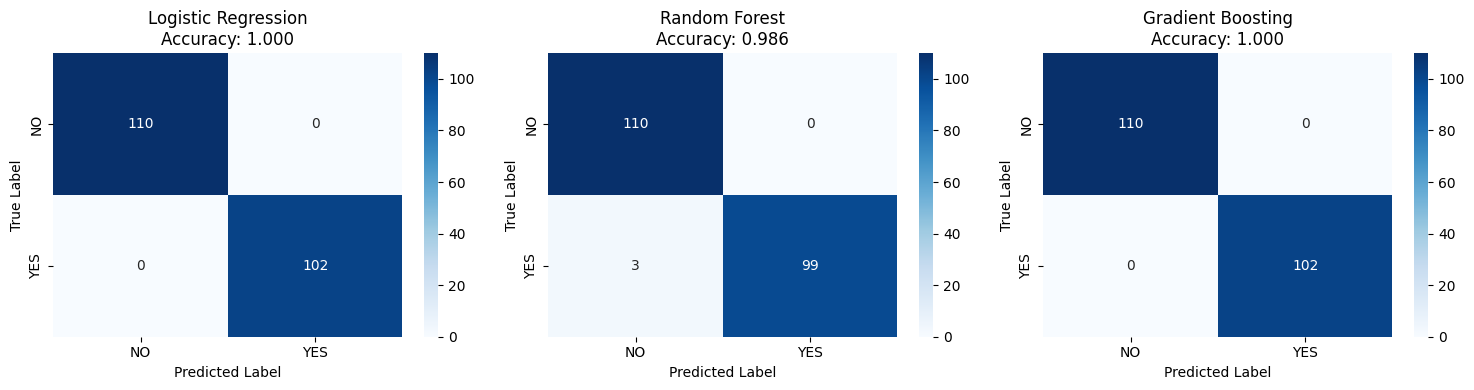

✅ Saved to: results/03_confusion_matrices.png


In [11]:
# Confusion matrices for best model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [('Logistic Regression', y_pred_lr), 
          ('Random Forest', y_pred_rf), 
          ('Gradient Boosting', y_pred_gb)]

for idx, (name, pred) in enumerate(models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.3f}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('../results/03_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Saved to: results/03_confusion_matrices.png')

## Step 9: ROC Curve Comparison

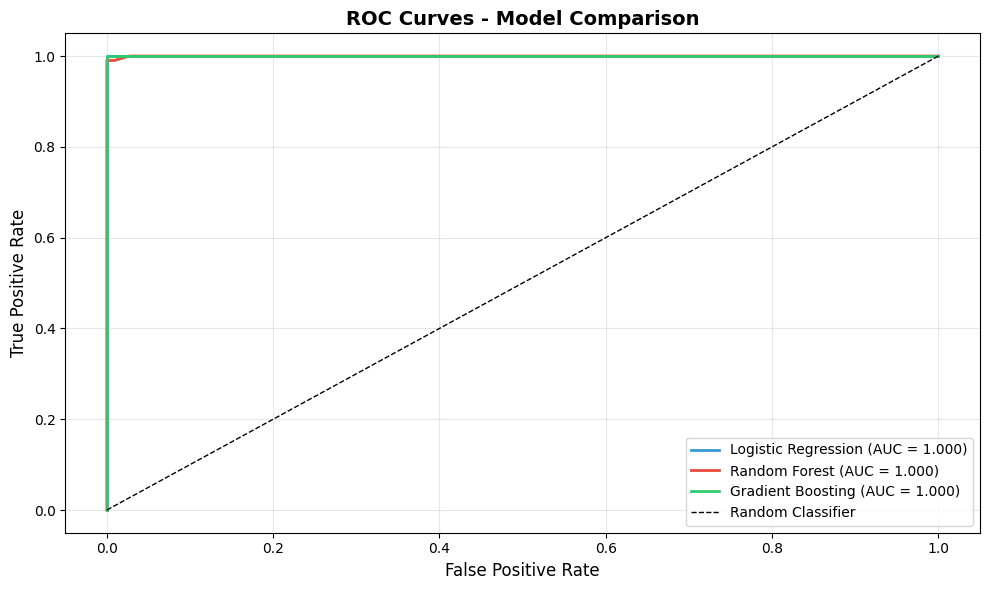

✅ Saved to: results/04_roc_curves.png


In [12]:
# ROC curves
plt.figure(figsize=(10, 6))

models_roc = [
    ('Logistic Regression', y_pred_proba_lr, roc_auc_score(y_test, y_pred_proba_lr)),
    ('Random Forest', y_pred_proba_rf, roc_auc_score(y_test, y_pred_proba_rf)),
    ('Gradient Boosting', y_pred_proba_gb, roc_auc_score(y_test, y_pred_proba_gb))
]

colors = ['#3498db', '#e74c3c', '#2ecc71']

for (name, proba, auc_score), color in zip(models_roc, colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2, color=color)

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/04_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Saved to: results/04_roc_curves.png')

## Step 10: Feature Importance Analysis

📊 TOP 10 IMPORTANT FEATURES (Random Forest)
                         Feature  Importance
         A9_focused_on_one_topic    0.146957
A1_prefer_detail_not_big_picture    0.132424
       A4_feel_anxious_in_social    0.130994
        A10_difficult_small_talk    0.125806
           A2_must_have_sameness    0.103019
                             age    0.094215
                         country    0.039866
                       ethnicity    0.036560
A3_prefer_reading_systematically    0.023072
    A7_trouble_focus_on_changing    0.021792


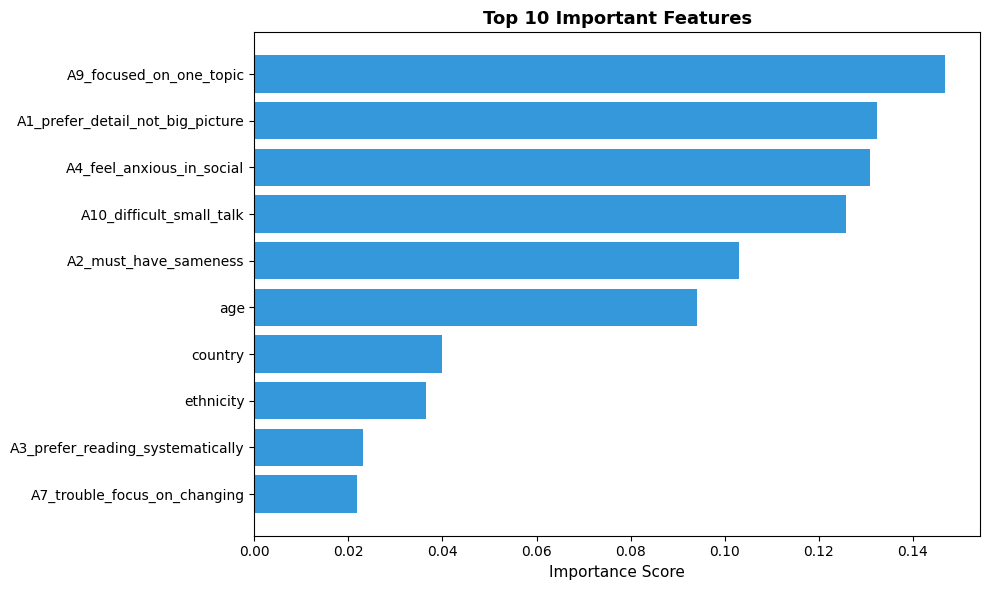


✅ Saved to: results/05_feature_importance.png


In [13]:
# Feature importance from Random Forest (best model)
feature_importance_rf = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('📊 TOP 10 IMPORTANT FEATURES (Random Forest)')
print('='*50)
print(feature_importance_rf.head(10).to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
top_n = 10
top_features = feature_importance_rf.head(top_n)

ax.barh(range(len(top_features)), top_features['Importance'], color='#3498db')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title(f'Top {top_n} Important Features', fontsize=13, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../results/05_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✅ Saved to: results/05_feature_importance.png')

## Step 11: Save Models

In [14]:
import pickle

# Save best model (Random Forest)
with open('../models/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save encoders
with open('../models/le_dict.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

with open('../models/le_target.pkl', 'wb') as f:
    pickle.dump(le_target, f)

# Save feature names
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(X_encoded.columns.tolist(), f)

print('✅ All models saved to: models/')
print('   - rf_model.pkl (Random Forest)')
print('   - scaler.pkl (StandardScaler)')
print('   - le_dict.pkl (Categorical Encoders)')
print('   - le_target.pkl (Target Encoder)')
print('   - feature_names.pkl (Feature Names)')

✅ All models saved to: models/
   - rf_model.pkl (Random Forest)
   - scaler.pkl (StandardScaler)
   - le_dict.pkl (Categorical Encoders)
   - le_target.pkl (Target Encoder)
   - feature_names.pkl (Feature Names)


## Step 12: Final Summary

In [15]:
print('\n' + '='*60)
print('🎯 MODEL TRAINING COMPLETE')
print('='*60)

print('\n✅ Best Performing Model: Random Forest')
print(f'   Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'   ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}')
print(f'   Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'   Recall: {recall_score(y_test, y_pred_rf):.4f}')

print('\n📊 Outputs Generated:')
print('   - Confusion matrices visualization')
print('   - ROC curves comparison')
print('   - Feature importance analysis')
print('   - Trained models saved')

print('\n🚀 Next Step: Build Explainability Layer (SHAP)')
print('   - Generate SHAP values')
print('   - Create interpretable explanations')
print('   - Build UI for predictions')


🎯 MODEL TRAINING COMPLETE

✅ Best Performing Model: Random Forest
   Accuracy: 0.9858
   ROC-AUC: 0.9998
   Precision: 1.0000
   Recall: 0.9706

📊 Outputs Generated:
   - Confusion matrices visualization
   - ROC curves comparison
   - Feature importance analysis
   - Trained models saved

🚀 Next Step: Build Explainability Layer (SHAP)
   - Generate SHAP values
   - Create interpretable explanations
   - Build UI for predictions
